# LLM_powered JD creator and then resume checker based on the resume and response accordingly

In [ ]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_groq import ChatGroq


In [ ]:
llm_groq=ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.9
)

In [ ]:
class llm_prompt_state(TypedDict):
    job_title:str
    response:str
    JD:str
    resume:str
    
    

In [ ]:
def create_jd(state:llm_prompt_state)->llm_prompt_state:
    job_post=state['job_title']
    prompt=f"you are a creative assistant who create job description for job role :{job_post} to post in linkedin in proper manner ."
    response=llm_groq.invoke(prompt)
    state['JD']=response.content
    return state

In [ ]:
def check_resume(state:llm_prompt_state)->llm_prompt_state:
    job_desc=state['JD']
    prompt="""You are an Applicant Tracking System (ATS) and a corporate HR screener for a Data Analyst position.

Your job is NOT to give explanations or long feedback.
Your job is to SCREEN the candidate quickly like a real recruiter who reviews resumes in under 30 seconds.

You will receive:
JOB DESCRIPTION:
{job_desc}

RESUME:
{resume}

Important Rules:
- Be strict and realistic
- Assume high competition
- Evaluate for an entry-level/junior Data Analyst role
- No motivational advice
- No paragraphs
- No storytelling
- Return ONLY structured output
- If you break the format, the output is invalid

You must evaluate based on:
• Skills match
• Required tools match
• Project relevance
• ATS keyword presence
• Data analysis evidence
• Resume clarity
• Hireability

Scoring Criteria:
ATS Score (0–100)
80+ = Strong Shortlist
70–79 = Shortlist
60–69 = Borderline
50–59 = Reject
Below 50 = Strong Reject

Now perform evaluation and return ONLY the following JSON:

{
  "ATS_score": number,
  "decision": "Strong Shortlist | Shortlist | Borderline | Reject | Strong Reject",
  "selected_for_interview": "YES | NO",
  "skills_match_percent": number,
  "missing_critical_skills": [list],
  "missing_keywords": [list],
  "project_relevance": "High | Medium | Low",
  "experience_level_fit": "Good | Average | Poor",
  "resume_strengths": [3 short bullet points],
  "major_weaknesses": [3 short bullet points],
  "top_5_improvements_needed": [5 short action points]
}

Do not add any text before or after the JSON.
"""
    check_resume=llm_groq.invoke(prompt)

    state['response']=check_resume
    return state

In [ ]:
graph=StateGraph(llm_prompt_state)
graph.add_node("JD_creator",create_jd)
graph.add_node("resume_check",check_resume)

graph.add_edge(START,"JD_creator")
graph.add_edge("JD_creator","resume_check")
graph.add_edge("resume_check",END)

workflow=graph.compile()

In [ ]:
initial_state={"job_title":"data analyst","resume":"""Vinay Kumar Rout
Ranaghat, West Bengal, India
📞 Phone: +91-XXXXXXXXXX
📧 Email: yourmail@gmail.com

🔗 LinkedIn: linkedin.com/in/yourprofile
🔗 GitHub: github.com/yourusername
🔗 Portfolio: yourwebsite.com (if created)

PROFESSIONAL SUMMARY

Motivated and detail-oriented Computer Science student with strong foundations in data analysis, Python programming, and applied AI tools. Skilled in data cleaning, visualization, and extracting insights from structured and unstructured datasets. Experienced in working with APIs, automation, and building data-driven applications. Passionate about transforming raw data into meaningful business insights using analytical and statistical techniques.

TECHNICAL SKILLS

Programming Languages:
Python, SQL, JavaScript (Basic)

Data Analysis & Visualization:
Pandas, NumPy, Matplotlib, Seaborn, Plotly, Excel

Databases:
MySQL, SQLite, Firebase (Basic)

Tools & Platforms:
Jupyter Notebook, Google Colab, Power BI (Basic), Git, GitHub, VS Code

AI & Automation Tools:
OpenAI API, LangChain, FastAPI, Web APIs, JSON handling, Web scraping

Other Skills:
Data Cleaning, Exploratory Data Analysis (EDA), Dashboard creation, API data extraction, Automation scripting

PROJECTS
1. Smart Distance Monitoring & Dashboard System

Developed an ESP32 based sensor system to collect real-time distance data.

Integrated sensor data with a Python backend using FastAPI.

Stored and analyzed data for behavioral patterns.

Created a simple web dashboard to visualize sensor readings.

Technologies: Python, FastAPI, JSON, ESP32, APIs

2. AI-Powered Assistant Data Logger

Built a voice-command assistant that converts speech into structured JSON data.

Automated task logging and information storage.

Used LLM APIs to process natural language input.

Extracted meaningful information from unstructured user queries.

Technologies: Python, Speech Recognition, LLM APIs, JSON, Automation

3. Website Analytics Tracker

Created a custom event tracking system for a personal website.

Recorded user interactions and page visits.

Analyzed visitor behavior to understand engagement patterns.

Technologies: JavaScript, Python, Data logging

4. Automated File Encryption & Processing Tool

Developed a Python application for file handling and secure processing.

Automated reading, transformation, and storage of datasets.

Technologies: Python, File handling, Automation

EDUCATION

Bachelor of Technology (B.Tech) — Computer Science Engineering
O.P. Jindal University, Raigarh, Chhattisgarh
Expected Graduation: 2027

Relevant Coursework:

Data Structures

Database Management Systems

Statistics (Basics)

Operating Systems

Python Programming

CERTIFICATIONS

Campus Ambassador – IIT Delhi EDC

LinkedIn Learning / Online Certifications (Add your actual certificates here)

Python Programming Certification (if any — add later)

EXPERIENCE (ACADEMIC / PRACTICAL)

Freelance / Personal Projects – Data Handling & Automation

Collected, processed, and analyzed datasets using Python.

Built automation scripts to clean and organize data.

Worked with APIs to extract and transform data into usable format.

ACHIEVEMENTS

Scored 92% in Class 12 Board Examination

Coordinator of college art & craft event (Kalakriti – Technorolix Fest)

Built multiple real-world technical projects involving data and automation

SOFT SKILLS

Analytical Thinking

Problem Solving

Attention to Detail

Communication

Logical Reasoning

Quick Learner

INTERESTS

Data Analysis & Visualization

Artificial Intelligence Applications

Automation Systems

Building Practical Tech Solutions"""}

In [ ]:
output_state=workflow.invoke(initial_state)
output_state

{'job_title': 'data analyst',
 'response': AIMessage(content='{\n  "ATS_score": 72,\n  "decision": "Shortlist",\n  "selected_for_interview": "YES",\n  "skills_match_percent": 85,\n  "missing_critical_skills": ["Machine Learning", "Cloud Computing"],\n  "missing_keywords": ["Data Visualization Tools", " Statistical Modeling"],\n  "project_relevance": "Medium",\n  "experience_level_fit": "Average",\n  "resume_strengths": [\n    "Strong educational background",\n    "Relevant internship experience",\n    "Good understanding of data analysis concepts"\n  ],\n  "major_weaknesses": [\n    "Lack of professional experience",\n    "Limited technical skills",\n    "No certifications mentioned"\n  ],\n  "top_5_improvements_needed": [\n    "Add relevant certifications",\n    "Include projects with machine learning",\n    "Mention cloud computing experience",\n    "Highlight data visualization skills",\n    "Emphasize statistical modeling knowledge"\n  ]\n}', additional_kwargs={}, response_metadata

In [ ]:
output_state["response"].content 

'{\n  "ATS_score": 72,\n  "decision": "Shortlist",\n  "selected_for_interview": "YES",\n  "skills_match_percent": 85,\n  "missing_critical_skills": ["Machine Learning", "Cloud Computing"],\n  "missing_keywords": ["Data Visualization Tools", " Statistical Modeling"],\n  "project_relevance": "Medium",\n  "experience_level_fit": "Average",\n  "resume_strengths": [\n    "Strong educational background",\n    "Relevant internship experience",\n    "Good understanding of data analysis concepts"\n  ],\n  "major_weaknesses": [\n    "Lack of professional experience",\n    "Limited technical skills",\n    "No certifications mentioned"\n  ],\n  "top_5_improvements_needed": [\n    "Add relevant certifications",\n    "Include projects with machine learning",\n    "Mention cloud computing experience",\n    "Highlight data visualization skills",\n    "Emphasize statistical modeling knowledge"\n  ]\n}'

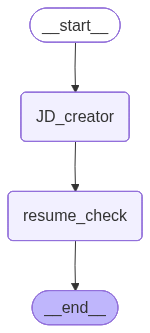

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
